# DLIS to WITSML testing

Based on a rather complex, large DLIS file from the published _Kentish Knock South 1_ data set,
containing a multiple arrays, this jupyter note book
- Reads the DLIS and provides a file summary
  - Number of logical files
  - Number of frames and channels
- Lists the available curves and dimensions (Dimension >1 means the curve is an array) in the DLIS 
    - Compared with other application parsers (SLB DLIS info view and AspenTech geolog) the results are consistent!
- Plots the CMR T2_distribution, similar to the right track of the [pdf plot](https://gitlab.opengroup.org/osdu/subcommittees/data-def/docs/-/blob/master/Design%20Documents/CrossDomains%20WellLog%20Extension%20Meetings/KKS1/CMR_Processing/Plot/Chevron_KKS1_CMR-DMRP_Processed.PDF?ref_type=heads)
- Convert the DLIS data into WITSML 1.4.1.1 format, then read the newly made xml file and redo the same CMR T2_distribution plot
- Convert the DLIS data into WITSML 2.1 format, then read the newly made xml file and redo the same CMR T2_distribution plot

## Load DLIS file
Open the source DLIS and list the available logical files.

In [1]:
import dlisio
from dlisio import dlis

# Open the DLIS file
f, *tail = dlis.load(r'./files/Chevron_KKS1_CMR-MainPass_Processed.dlis')
logical_files = [f] + tail

print("=== FILE SUMMARY ===")
print(f"Number of logical files: {len(logical_files)}")
print()

# Describe all logical files
for i, lf in enumerate(logical_files):
    print(f"=== LOGICAL FILE {i} ===")
    print(lf.describe())
    print()


=== FILE SUMMARY ===
Number of logical files: 1

=== LOGICAL FILE 0 ===
------------
Logical File
------------
Description : LogicalFile(1)
Frames      : 1
Channels    : 96

Known objects
--
FILE-HEADER : 1
AXIS        : 1
PARAMETER   : 37
FRAME       : 1
CHANNEL     : 96
PROCESS     : 1
ORIGIN      : 2





## Inspect channel metadata
Display the DLIS channel list so the available curves and dimensions are easy to compare.

In [2]:
import pandas as pd

# Show all channels as a DataFrame for each logical file
for i, lf in enumerate(logical_files):
    channel_data = []
    for ch in lf.channels:
        channel_data.append({
            'Name': ch.name,
            'Long Name': ch.long_name,
            'Units': ch.units,
            'Dimension': ch.dimension,
            'Repr Code': ch.reprc,
        })

    df_channels = pd.DataFrame(channel_data)
    print(f"=== LOGICAL FILE {i} — TOTAL CHANNELS: {len(df_channels)} ===")
    display(df_channels)
    print()


=== LOGICAL FILE 0 — TOTAL CHANNELS: 96 ===


,Name,Long Name,Units,Dimension,Repr Code
0,WSUM,Window Sums,,[20],2
1,NOISE_PWR,Noise Power Computed Down-Hole,,[2],2
2,SPHASE,Signal Phase,deg,[2],2
3,ECHO_AMP_AP,A+ Component of CMR Spin Echoes,,[5030],2
4,ECHO_AMP_AM,A- Component of CMR Spin Echoes,,[5030],2
...,...,...,...,...,...
91,OVIS_KV,Oil Viscosity from Kleinberg-Vinegar Method,Pa.s,[1],2
92,T2LM_KV,T2 Logarithmic Mean used in Kleinberg-Vinegar ...,ms,[1],2
93,QNMR,Normalized Flow from NMR Permeability,,[1],2
94,QMRK,Flow Marker,,[1],2


## Plot DLIS T2 distribution
Render the original DLIS-based T2 distribution heatmap and T2LM overlay.

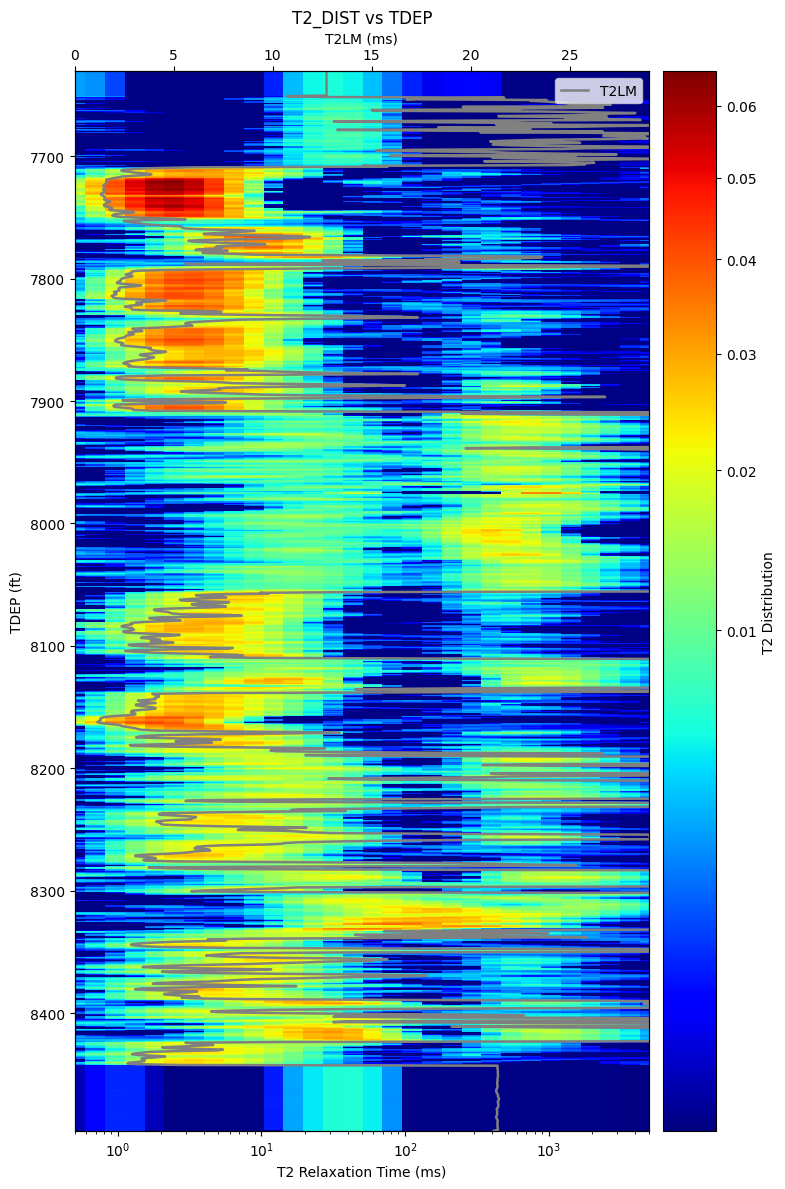

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Select logical file (change index for multiple files)
lf = logical_files[0]
frame = lf.frames[0]
curves = frame.curves()

tdep = curves['TDEP']
t2_dist = curves['T2_DIST']
t2lm = curves['T2LM']

# T2 bins log-spaced from 0.5 ms to 5000 ms
n_bins = t2_dist.shape[1]
t2_bins = np.logspace(np.log10(0.5), np.log10(5000), n_bins)

fig, ax = plt.subplots(figsize=(8, 12))
im = ax.pcolormesh(
    t2_bins, tdep, t2_dist,
    shading='auto', cmap='jet',
    norm=PowerNorm(gamma=0.4)
)
ax.set_xscale('log')
ax.set_xlim(0.5, 5000)
ax.set_xlabel('T2 Relaxation Time (ms)')
ax.set_ylabel('TDEP (ft)')
ax.set_title('T2_DIST vs TDEP')
ax.invert_yaxis()
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('T2 Distribution')

# Overlay T2LM curve on a secondary x-axis
ax2 = ax.twiny()
ax2.plot(t2lm.flatten(), tdep, color='gray', linewidth=1.8, label='T2LM')
ax2.set_xlim(0, 29)
ax2.set_xlabel('T2LM (ms)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Export WITSML 1.4.1.1
Write the full log, including array channels, to the WITSML 1.4.1.1 file.

In [4]:
import xml.etree.ElementTree as ET
from xml.dom import minidom
import numpy as np

# Convert DLIS to WITSML 1.4.1.1 log format (include scalar + array channels)
lf = logical_files[0]
frame = lf.frames[0]
curves = frame.curves()
origin = lf.origins[0] if lf.origins else None

# Export all channels, not only scalar ones
all_channels = list(frame.channels)
print(f"Exporting {len(all_channels)} channels (including arrays)")

# WITSML namespace
NS = "http://www.witsml.org/schemas/1series"
ET.register_namespace('', NS)

def ns(tag):
    return f"{{{NS}}}{tag}"

# Build WITSML XML
root = ET.Element(ns("logs"), version="1.4.1.1")
log = ET.SubElement(root, ns("log"))

# Header info from origin
if origin:
    ET.SubElement(log, ns("nameWell")).text = str(origin.well_name or "Unknown")
    ET.SubElement(log, ns("nameWellbore")).text = str(origin.well_name or "Unknown")
    ET.SubElement(log, ns("name")).text = frame.name or "Log"

# Index type
index_ch = frame.index
ET.SubElement(log, ns("indexType")).text = "measured depth"
ET.SubElement(log, ns("startIndex"), uom="ft").text = str(float(curves[index_ch].min()))
ET.SubElement(log, ns("endIndex"), uom="ft").text = str(float(curves[index_ch].max()))

# Log curve info
for ch in all_channels:
    lci = ET.SubElement(log, ns("logCurveInfo"))
    ET.SubElement(lci, ns("mnemonic")).text = ch.name

    if ch.units:
        ET.SubElement(lci, ns("unit")).text = str(ch.units)

    desc_parts = []
    if ch.long_name:
        desc_parts.append(ch.long_name if isinstance(ch.long_name, str) else str(ch.long_name))
    if ch.dimension and ch.dimension != [1]:
        desc_parts.append(f"dimension={ch.dimension}")
    if desc_parts:
        ET.SubElement(lci, ns("curveDescription")).text = " | ".join(desc_parts)

    if ch.name == index_ch:
        ET.SubElement(lci, ns("typeLogData")).text = "double"
        ET.SubElement(lci, ns("classIndex")).text = "1"
    elif ch.dimension == [1]:
        ET.SubElement(lci, ns("typeLogData")).text = "double"
    else:
        # Arrays are serialized as bracketed, space-separated strings in <data> rows
        ET.SubElement(lci, ns("typeLogData")).text = "string"

# Log data
log_data = ET.SubElement(log, ns("logData"))

# Mnemonics header
ET.SubElement(log_data, ns("mnemonicList")).text = ",".join(ch.name for ch in all_channels)
ET.SubElement(log_data, ns("unitList")).text = ",".join(str(ch.units or "") for ch in all_channels)

# Data rows
n_rows = len(curves[index_ch])
for i in range(n_rows):
    values = []
    for ch in all_channels:
        val = curves[ch.name][i]

        if ch.dimension == [1]:
            # Scalar values
            if hasattr(val, '__len__') and not isinstance(val, (str, bytes)):
                val = val[0]
            val = float(val)
            if np.isnan(val):
                values.append("")
            else:
                values.append(f"{val:.6g}")
        else:
            # Array values: keep full content as [v1 v2 ...]
            arr = np.asarray(val).flatten()
            arr_str = " ".join("" if np.isnan(x) else f"{x:.6g}" for x in arr)
            values.append(f"[{arr_str}]")

    ET.SubElement(log_data, ns("data")).text = ",".join(values)

# Write to file
xml_str = ET.tostring(root, encoding='unicode', xml_declaration=False)
xml_pretty = minidom.parseString(xml_str).toprettyxml(indent="  ", encoding="utf-8")

output_path = r'./files/Chevron_KKS1_CMR-MainPass_Processed.xml'
with open(output_path, 'wb') as wf:
    wf.write(xml_pretty)

print(f"WITSML file written to: {output_path}")
print(f"Rows: {n_rows}, Channels: {len(all_channels)} (including array channels)")

Exporting 96 channels (including arrays)
WITSML file written to: ./files/Chevron_KKS1_CMR-MainPass_Processed.xml
Rows: 1385, Channels: 96 (including array channels)


## Plot WITSML 1.4.1.1 data
Read the 1.4.1.1 XML back and render the full T2 distribution heatmap.

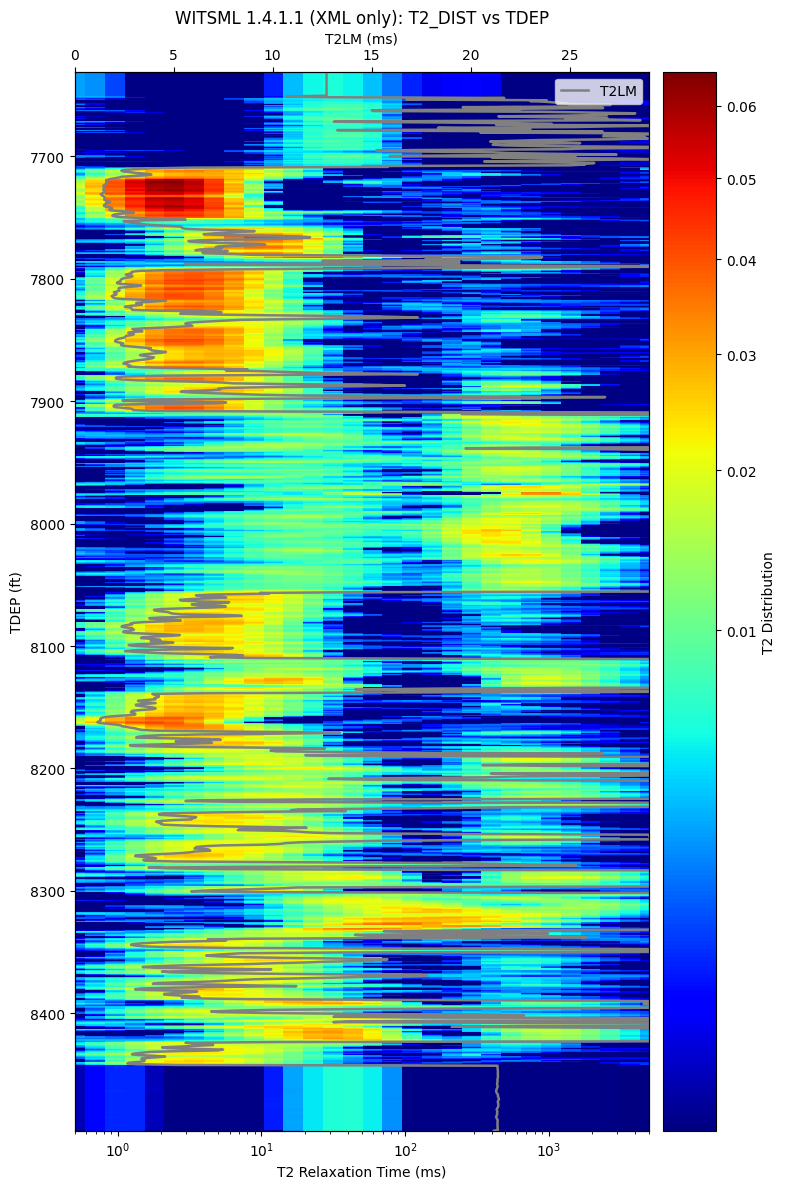

Parsed rows from XML: 1385
T2_DIST bins used: 30


In [5]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Read WITSML 1.4.1.1 XML (XML data only)
xml_path = r'./files/Chevron_KKS1_CMR-MainPass_Processed.xml'
ns = {'w': 'http://www.witsml.org/schemas/1series'}

root = ET.parse(xml_path).getroot()
log = root.find('w:log', ns)
if log is None:
    raise ValueError('No <log> found in WITSML 1.4.1.1 XML.')

log_data = log.find('w:logData', ns)
if log_data is None:
    raise ValueError('No <logData> found in WITSML 1.4.1.1 XML.')

mnemonic_text = log_data.findtext('w:mnemonicList', default='', namespaces=ns)
mnemonics = [m.strip() for m in mnemonic_text.split(',') if m.strip()]
if not mnemonics:
    raise ValueError('mnemonicList is empty in WITSML 1.4.1.1 XML.')

col_idx = {m: i for i, m in enumerate(mnemonics)}
required = ['TDEP', 'T2LM', 'T2_DIST']
missing = [m for m in required if m not in col_idx]
if missing:
    raise KeyError(f'Missing required mnemonic(s): {missing}')

# Parse data rows with bracket-aware CSV splitting
rows = []
for data_elem in log_data.findall('w:data', ns):
    line = (data_elem.text or '').strip()
    if not line:
        continue

    vals = []
    token = ''
    in_brackets = False
    for ch in line:
        if ch == '[':
            in_brackets = True
            token += ch
        elif ch == ']':
            in_brackets = False
            token += ch
        elif ch == ',' and not in_brackets:
            vals.append(token.strip())
            token = ''
        else:
            token += ch
    vals.append(token.strip())

    if len(vals) < len(mnemonics):
        vals += [''] * (len(mnemonics) - len(vals))
    rows.append(vals[:len(mnemonics)])

if not rows:
    raise ValueError('No log data rows found in XML file.')

# Extract scalar curves
tdep = np.full(len(rows), np.nan, dtype=float)
t2lm = np.full(len(rows), np.nan, dtype=float)

# Extract array curve (full T2_DIST content)
t2_dist_list = []
for i, r in enumerate(rows):
    try:
        if r[col_idx['TDEP']]:
            tdep[i] = float(r[col_idx['TDEP']])
    except ValueError:
        pass

    try:
        if r[col_idx['T2LM']]:
            t2lm[i] = float(r[col_idx['T2LM']])
    except ValueError:
        pass

    arr_txt = r[col_idx['T2_DIST']]
    if arr_txt.startswith('[') and arr_txt.endswith(']'):
        core = arr_txt[1:-1].strip()
        if core:
            arr = np.array([float(v) if v else np.nan for v in core.split()], dtype=float)
        else:
            arr = np.array([], dtype=float)
    else:
        arr = np.array([], dtype=float)

    t2_dist_list.append(arr)

# Build 2D matrix preserving full array content
n_bins = max((a.size for a in t2_dist_list), default=0)
if n_bins == 0:
    raise ValueError('T2_DIST arrays were not found in WITSML 1.4.1.1 XML.')

t2_dist = np.full((len(t2_dist_list), n_bins), np.nan, dtype=float)
for i, arr in enumerate(t2_dist_list):
    if arr.size == 0:
        continue
    t2_dist[i, :arr.size] = arr

# T2 bins (log-spaced, consistent with DLIS workflow)
t2_bins = np.logspace(np.log10(0.5), np.log10(5000), n_bins)

# Sort by depth for stable plotting
valid = np.isfinite(tdep)
if valid.sum() < 2:
    raise ValueError('Not enough valid TDEP values in XML to plot.')

order = np.argsort(tdep[valid])
tdep_plot = tdep[valid][order]
t2_dist_plot = t2_dist[valid, :][order, :]
t2lm_plot = t2lm[valid][order]

# Filter invalid/sentinel T2LM and keep DLIS-style axis
t2lm_plot = np.where((t2lm_plot > 0) & (t2lm_plot < 100), t2lm_plot, np.nan)

fig, ax = plt.subplots(figsize=(8, 12))
im = ax.pcolormesh(
    t2_bins,
    tdep_plot,
    t2_dist_plot,
    shading='auto',
    cmap='jet',
    norm=PowerNorm(gamma=0.4)
)

ax.set_xscale('log')
ax.set_xlim(np.nanmin(t2_bins), np.nanmax(t2_bins))
ax.set_xlabel('T2 Relaxation Time (ms)')
ax.set_ylabel('TDEP (ft)')
ax.set_title('WITSML 1.4.1.1 (XML only): T2_DIST vs TDEP')
ax.invert_yaxis()

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('T2 Distribution')

ax2 = ax.twiny()
ax2.plot(t2lm_plot, tdep_plot, color='gray', linewidth=1.8, label='T2LM')
ax2.set_xlim(0, 29)
ax2.set_xlabel('T2LM (ms)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f'Parsed rows from XML: {len(rows)}')
print(f'T2_DIST bins used: {n_bins}')

## Export WITSML 2.1
Write the full log, including array channels, to the WITSML 2.1 file.

In [6]:
import xml.etree.ElementTree as ET
from xml.dom import minidom
import numpy as np
import uuid
from datetime import datetime

# Convert DLIS to WITSML 2.1 Log format (includes array channels)
lf = logical_files[0]
frame = lf.frames[0]
curves = frame.curves()
origin = lf.origins[0] if lf.origins else None

# Namespaces
NS_WITSML = "http://www.energistics.org/energyml/data/witsmlv2"
NS_EML = "http://www.energistics.org/energyml/data/commonv2"
ET.register_namespace('', NS_WITSML)
ET.register_namespace('eml', NS_EML)

def wns(tag):
    return f"{{{NS_WITSML}}}{tag}"

def ens(tag):
    return f"{{{NS_EML}}}{tag}"

# Build WITSML 2.1 XML
root = ET.Element(wns("Log"),
    attrib={"schemaVersion": "2.1",
            f"{{{NS_EML}}}uuid": str(uuid.uuid4())})

# Citation
citation = ET.SubElement(root, ens("Citation"))
ET.SubElement(citation, ens("Title")).text = frame.name or "CMR Log"
ET.SubElement(citation, ens("Creation")).text = datetime.now().isoformat()
ET.SubElement(citation, ens("Format")).text = "dlisio Python export"

# Well info
if origin:
    ET.SubElement(root, wns("WellName")).text = str(origin.well_name or "Unknown")
    ET.SubElement(root, wns("WellboreName")).text = str(origin.well_name or "Unknown")

# ChannelSet
channel_set = ET.SubElement(root, wns("ChannelSet"))
cs_citation = ET.SubElement(channel_set, ens("Citation"))
ET.SubElement(cs_citation, ens("Title")).text = frame.name or "Main Frame"

# Index definition
index_ch = frame.index
index_elem = ET.SubElement(channel_set, wns("Index"))
ET.SubElement(index_elem, wns("Mnemonic")).text = index_ch
index_channel_obj = next((ch for ch in frame.channels if ch.name == index_ch), None)
ET.SubElement(index_elem, wns("Uom")).text = str(index_channel_obj.units) if index_channel_obj else "ft"
ET.SubElement(index_elem, wns("IndexKind")).text = "measured depth"
ET.SubElement(index_elem, wns("Direction")).text = "increasing"

# Channel definitions (all channels including arrays)
all_channels = [ch for ch in frame.channels if ch.name != index_ch]
print(f"Exporting {len(all_channels)} channels (including multi-dimensional)")

for ch in all_channels:
    channel_elem = ET.SubElement(channel_set, wns("Channel"))
    ch_citation = ET.SubElement(channel_elem, ens("Citation"))
    ET.SubElement(ch_citation, ens("Title")).text = ch.name
    ET.SubElement(channel_elem, wns("Mnemonic")).text = ch.name
    if ch.units:
        ET.SubElement(channel_elem, wns("Uom")).text = str(ch.units)
    if ch.long_name:
        ln = ch.long_name if isinstance(ch.long_name, str) else str(ch.long_name)
        ET.SubElement(channel_elem, wns("Description")).text = ln

    # Data type
    dim = ch.dimension
    if dim == [1]:
        ET.SubElement(channel_elem, wns("DataType")).text = "double"
    else:
        ET.SubElement(channel_elem, wns("DataType")).text = "double array"
        # Axis definition for array channels
        axis_def = ET.SubElement(channel_elem, wns("AxisDefinition"))
        ET.SubElement(axis_def, wns("Order")).text = "1"
        count = dim[0] if dim else 1
        ET.SubElement(axis_def, wns("Count")).text = str(count)
        # For T2 distributions, provide log-spaced axis values
        if 'T2' in ch.name:
            axis_vals = np.logspace(np.log10(0.5), np.log10(5000), count)
            ET.SubElement(axis_def, wns("DoubleValues")).text = " ".join(f"{v:.4g}" for v in axis_vals)

# Data section - WITSML 2.1 uses JSON-like inline data
data_elem = ET.SubElement(channel_set, wns("Data"))

# MnemonicList
ET.SubElement(data_elem, wns("MnemonicList")).text = index_ch + "," + ",".join(ch.name for ch in all_channels)

# Data rows: scalar values as-is, arrays as space-separated within brackets
n_rows = len(curves[index_ch])
for i in range(n_rows):
    row_values = []
    # Index value
    idx_val = float(curves[index_ch][i])
    row_values.append(f"{idx_val:.4f}")
    # Channel values
    for ch in all_channels:
        val = curves[ch.name][i]
        if ch.dimension == [1]:
            v = float(val) if not hasattr(val, '__len__') else float(val[0])
            row_values.append("" if np.isnan(v) else f"{v:.6g}")
        else:
            # Array channel: space-separated values inside brackets
            arr = val.flatten()
            arr_str = " ".join("" if np.isnan(x) else f"{x:.6g}" for x in arr)
            row_values.append(f"[{arr_str}]")
    ET.SubElement(data_elem, wns("Data")).text = ",".join(row_values)

# Write to file
xml_str = ET.tostring(root, encoding='unicode', xml_declaration=False)
xml_decl = '<?xml version="1.0" encoding="utf-8"?>\n'
# Use minidom for pretty printing (only header, not data rows for file size)
xml_pretty = minidom.parseString(xml_str).toprettyxml(indent="  ", encoding="utf-8")

output_path = r'./files/Chevron_KKS1_CMR-MainPass_Processed_v21.xml'
with open(output_path, 'wb') as wf:
    wf.write(xml_pretty)

print(f"WITSML 2.1 file written to: {output_path}")
print(f"Rows: {n_rows}, Channels: {len(all_channels)} (incl. array channels)")


Exporting 95 channels (including multi-dimensional)
WITSML 2.1 file written to: ./files/Chevron_KKS1_CMR-MainPass_Processed_v21.xml
Rows: 1385, Channels: 95 (incl. array channels)


## Plot WITSML 2.1 data
Read the 2.1 XML back and render the full T2 distribution heatmap.

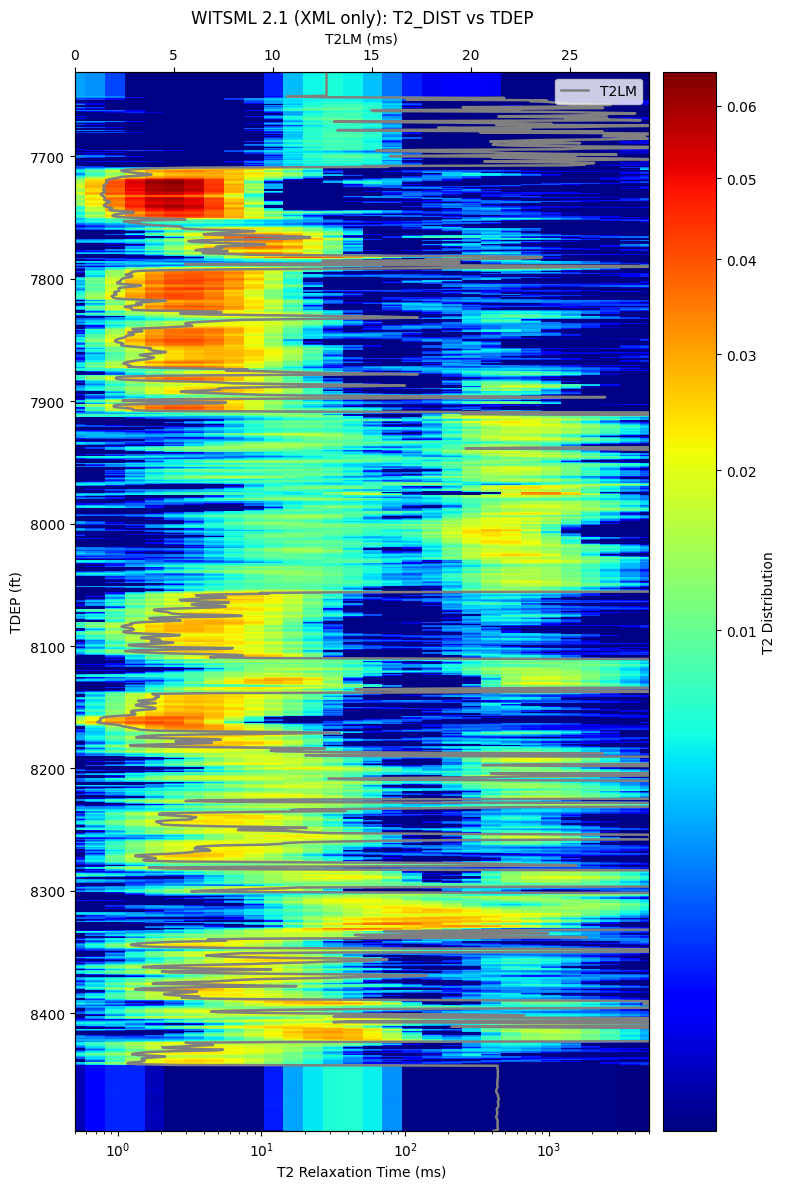

Parsed rows from WITSML 2.1 XML: 1385
T2_DIST bins used: 30


In [7]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Read WITSML 2.1 XML (XML data only)
xml_path_v21 = r'./files/Chevron_KKS1_CMR-MainPass_Processed_v21.xml'
ns_w = {'w': 'http://www.energistics.org/energyml/data/witsmlv2'}

root_v21 = ET.parse(xml_path_v21).getroot()
channel_set_v21 = root_v21.find('w:ChannelSet', ns_w)
if channel_set_v21 is None:
    raise ValueError('ChannelSet not found in WITSML 2.1 XML.')

data_block_v21 = channel_set_v21.find('w:Data', ns_w)
if data_block_v21 is None:
    raise ValueError('Data block not found in WITSML 2.1 XML.')

mnemonic_list_text = data_block_v21.findtext('w:MnemonicList', default='', namespaces=ns_w)
mnemonics_v21 = [m.strip() for m in mnemonic_list_text.split(',') if m.strip()]
if not mnemonics_v21:
    raise ValueError('MnemonicList is empty in WITSML 2.1 XML.')

midx = {m: i for i, m in enumerate(mnemonics_v21)}
if 'TDEP' not in midx or 'T2LM' not in midx or 'T2_DIST' not in midx:
    raise KeyError('Expected TDEP, T2LM and T2_DIST in WITSML 2.1 MnemonicList.')

# Parse channel axis values for T2_DIST bins (written in AxisDefinition/DoubleValues)
channel_elems = channel_set_v21.findall('w:Channel', ns_w)
t2_bins = None
for ch in channel_elems:
    m = ch.findtext('w:Mnemonic', default='', namespaces=ns_w).strip()
    if m == 'T2_DIST':
        axis = ch.find('w:AxisDefinition', ns_w)
        if axis is not None:
            axis_text = axis.findtext('w:DoubleValues', default='', namespaces=ns_w).strip()
            if axis_text:
                t2_bins = np.array([float(v) for v in axis_text.split()], dtype=float)
        break

if t2_bins is None or t2_bins.size == 0:
    # Fallback if axis values are not present
    t2_bins = np.logspace(np.log10(0.5), np.log10(5000), 64)

# Parse Data rows: scalar values are plain numbers, arrays are [v1 v2 ...]
rows_tdep = []
rows_t2lm = []
rows_t2dist = []

for row_elem in data_block_v21.findall('w:Data', ns_w):
    line = (row_elem.text or '').strip()
    if not line:
        continue

    vals = []
    token = ''
    in_brackets = False
    for ch in line:
        if ch == '[':
            in_brackets = True
            token += ch
        elif ch == ']':
            in_brackets = False
            token += ch
        elif ch == ',' and not in_brackets:
            vals.append(token.strip())
            token = ''
        else:
            token += ch
    vals.append(token.strip())

    if len(vals) < len(mnemonics_v21):
        vals += [''] * (len(mnemonics_v21) - len(vals))

    try:
        tdep_val = float(vals[midx['TDEP']]) if vals[midx['TDEP']] else np.nan
    except ValueError:
        tdep_val = np.nan

    try:
        t2lm_val = float(vals[midx['T2LM']]) if vals[midx['T2LM']] else np.nan
    except ValueError:
        t2lm_val = np.nan

    arr_txt = vals[midx['T2_DIST']]
    if arr_txt.startswith('[') and arr_txt.endswith(']'):
        arr_core = arr_txt[1:-1].strip()
        if arr_core:
            arr = np.array([float(v) if v else np.nan for v in arr_core.split()], dtype=float)
        else:
            arr = np.array([], dtype=float)
    else:
        arr = np.array([], dtype=float)

    rows_tdep.append(tdep_val)
    rows_t2lm.append(t2lm_val)
    rows_t2dist.append(arr)

if not rows_t2dist:
    raise ValueError('No data rows found in WITSML 2.1 XML.')

# Normalize array length to the available bins
target_bins = len(t2_bins)
t2dist_matrix = np.full((len(rows_t2dist), target_bins), np.nan, dtype=float)
for i, arr in enumerate(rows_t2dist):
    if arr.size == 0:
        continue
    n = min(target_bins, arr.size)
    t2dist_matrix[i, :n] = arr[:n]

tdep_arr = np.array(rows_tdep, dtype=float)
t2lm_arr = np.array(rows_t2lm, dtype=float)

valid = np.isfinite(tdep_arr)
if valid.sum() < 2:
    raise ValueError('Not enough valid TDEP values to plot.')

order = np.argsort(tdep_arr[valid])
tdep_plot = tdep_arr[valid][order]
t2dist_plot = t2dist_matrix[valid, :][order, :]
t2lm_plot = t2lm_arr[valid][order]

# Remove invalid/sentinel values from T2LM before plotting (match DLIS behavior)
t2lm_plot = np.where((t2lm_plot > 0) & (t2lm_plot < 100), t2lm_plot, np.nan)

# DLIS-style plot
fig, ax = plt.subplots(figsize=(8, 12))
im = ax.pcolormesh(
    t2_bins,
    tdep_plot,
    t2dist_plot,
    shading='auto',
    cmap='jet',
    norm=PowerNorm(gamma=0.4)
)

ax.set_xscale('log')
ax.set_xlim(np.nanmin(t2_bins), np.nanmax(t2_bins))
ax.set_xlabel('T2 Relaxation Time (ms)')
ax.set_ylabel('TDEP (ft)')
ax.set_title('WITSML 2.1 (XML only): T2_DIST vs TDEP')
ax.invert_yaxis()

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('T2 Distribution')

ax2 = ax.twiny()
ax2.plot(t2lm_plot, tdep_plot, color='gray', linewidth=1.8, label='T2LM')
ax2.set_xlim(0, 29)
ax2.set_xlabel('T2LM (ms)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f'Parsed rows from WITSML 2.1 XML: {len(rows_tdep)}')
print(f'T2_DIST bins used: {target_bins}')